# Advanced Retrieval with LangChain

In the following notebook, we'll explore various methods of advanced retrieval using LangChain!

We'll touch on:

- Naive Retrieval
- Best-Matching 25 (BM25)
- Multi-Query Retrieval
- Parent-Document Retrieval
- Contextual Compression (a.k.a. Rerank)
- Ensemble Retrieval
- Semantic chunking

We'll also discuss how these methods impact performance on our set of documents with a simple RAG chain.

There will be two breakout rooms:

- 🤝 Breakout Room Part #1
  - Task 1: Getting Dependencies!
  - Task 2: Data Collection and Preparation
  - Task 3: Setting Up QDrant!
  - Task 4-10: Retrieval Strategies
- 🤝 Breakout Room Part #2
  - Activity: Evaluate with Ragas

# 🤝 Breakout Room Part #1

## Task 1: Getting Dependencies!

We're going to need a few specific LangChain community packages, like OpenAI (for our [LLM](https://platform.openai.com/docs/models) and [Embedding Model](https://platform.openai.com/docs/guides/embeddings)) and Cohere (for our [Reranker](https://cohere.com/rerank)).

We'll also provide our OpenAI key, as well as our Cohere API key.

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

In [2]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

## Task 2: Data Collection and Preparation

We'll be using our Loan Data once again - this time the strutured data available through the CSV!

### Data Preparation

We want to make sure all our documents have the relevant metadata for the various retrieval strategies we're going to be applying today.

In [11]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from datetime import datetime, timedelta

loader = CSVLoader(
    file_path=f"./data/complaints.csv",
    metadata_columns=[
      "Date received", 
      "Product", 
      "Sub-product", 
      "Issue", 
      "Sub-issue", 
      "Consumer complaint narrative", 
      "Company public response", 
      "Company", 
      "State", 
      "ZIP code", 
      "Tags", 
      "Consumer consent provided?", 
      "Submitted via", 
      "Date sent to company", 
      "Company response to consumer", 
      "Timely response?", 
      "Consumer disputed?", 
      "Complaint ID"
    ]
)

loan_complaint_data = loader.load()

for doc in loan_complaint_data:
    doc.page_content = doc.metadata["Consumer complaint narrative"]

Let's look at an example document to see if everything worked as expected!

In [12]:
loan_complaint_data[0]

Document(metadata={'source': './data/complaints.csv', 'row': 0, 'Date received': '03/27/25', 'Product': 'Student loan', 'Sub-product': 'Federal student loan servicing', 'Issue': 'Dealing with your lender or servicer', 'Sub-issue': 'Trouble with how payments are being handled', 'Consumer complaint narrative': "The federal student loan COVID-19 forbearance program ended in XX/XX/XXXX. However, payments were not re-amortized on my federal student loans currently serviced by Nelnet until very recently. The new payment amount that is effective starting with the XX/XX/XXXX payment will nearly double my payment from {$180.00} per month to {$360.00} per month. I'm fortunate that my current financial position allows me to be able to handle the increased payment amount, but I am sure there are likely many borrowers who are not in the same position. The re-amortization should have occurred once the forbearance ended to reduce the impact to borrowers.", 'Company public response': 'None', 'Company'

## Task 3: Setting up QDrant!

Now that we have our documents, let's create a QDrant VectorStore with the collection name "LoanComplaints".

We'll leverage OpenAI's [`text-embedding-3-small`](https://openai.com/blog/new-embedding-models-and-api-updates) because it's a very powerful (and low-cost) embedding model.

> NOTE: We'll be creating additional vectorstores where necessary, but this pattern is still extremely useful.

In [13]:
from langchain_community.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Qdrant.from_documents(
    loan_complaint_data[:5],
    embeddings,
    location=":memory:",
    collection_name="LoanComplaints"
)

## Task 4: Naive RAG Chain

Since we're focusing on the "R" in RAG today - we'll create our Retriever first.

### R - Retrieval

This naive retriever will simply look at each review as a document, and use cosine-similarity to fetch the 10 most relevant documents.

> NOTE: We're choosing `10` as our `k` here to provide enough documents for our reranking process later

In [16]:
# XTALLET - modificado el k de 10 a 5
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 5})

### A - Augmented

We're going to go with a standard prompt for our simple RAG chain today! Nothing fancy here, we want this to mostly be about the Retrieval process.

In [17]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

### G - Generation

We're going to leverage `gpt-4.1-nano` as our LLM today, as - again - we want this to largely be about the Retrieval process.

In [18]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4.1-nano")

### LCEL RAG Chain

We're going to use LCEL to construct our chain.

> NOTE: This chain will be exactly the same across the various examples with the exception of our Retriever!

In [19]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

naive_retrieval_chain = (
    # INVOKE CHAIN WITH: {"question" : "<<SOME USER QUESTION>>"}
    # "question" : populated by getting the value of the "question" key
    # "context"  : populated by getting the value of the "question" key and chaining it into the base_retriever
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    # "context"  : is assigned to a RunnablePassthrough object (will not be called or considered in the next step)
    #              by getting the value of the "context" key from the previous step
    | RunnablePassthrough.assign(context=itemgetter("context"))
    # "response" : the "context" and "question" values are used to format our prompt object and then piped
    #              into the LLM and stored in a key called "response"
    # "context"  : populated by getting the value of the "context" key from the previous step
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's see how this simple chain does on a few different prompts.

> NOTE: You might think that we've cherry picked prompts that showcase the individual skill of each of the retrieval strategies - you'd be correct!

In [14]:
# XTALLET NEW
result = naive_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})

In [15]:
print(f'response : {result["response"].content}')
#test_row.eval_sample.consumer_narratives = [context.metadata["Consumer complaint narrative"] for context in response["context"]]
retrieved_context = [context.metadata["Consumer complaint narrative"] for context in result["context"]]
print(f'context : {retrieved_context}')

response : The most common issue with loans, based on the provided complaints, appears to be problems related to dealing with lenders or servicers. This includes issues such as receiving bad information about loans, difficulties with payment handling, lack of transparency and communication, and incorrect billing or payment amounts.
context : ['Since the resumption of federal loan payments I have received little to no contact last time I called they said I was in forbearance until 2040 but nothing in writing. I am having trouble logging in with my credentials and when you call for assistance there is a long wait then a disconnection once someone finally comes to the phone.lack of transparency and accountability has caused undue stress.', 'According to Studentaid.gov, Im to get an email and a letter of notice that my servicer is being changed. studentaid.gov says that my issuer is nelnet. Nelnet says my issuer is somewhere else. With that said, the only reason i would have know would be 

In [10]:
naive_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'The most common issue with loans, based on the provided complaints, appears to be mismanagement and errors in handling student loans. Specific examples include inaccuracies in loan balances and statuses, improper transfers of loan accounts without notice, technical issues with accessing or updating loan information, and unfair or confusing repayment practices such as improper application of payments or unjustified interest increases. Many complaints also highlight a lack of communication from servicers and difficulties in resolving disputes or obtaining accurate information.'

In [11]:
naive_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Based on the provided information, yes, some complaints were not handled in a timely manner. Specifically, at least one complaint (row 441) was marked as "Timely response?": "No," indicating it was not responded to within the expected timeframe. The complaint involved a delay in resolving issues related to your student loan application status, and it appears to have exceeded the expected response time by a significant margin.'

In [12]:
naive_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People often failed to pay back their loans due to several interconnected reasons highlighted in the complaints:\n\n1. **Lack of Clear Communication and Notification:** Many borrowers were not properly informed about the transfer of their loans between loan servicers or the exact date when repayment was to resume. This led to unexpected delinquency and missed payments. For example, some borrowers were unaware their loans had been transferred without notice, and others did not receive timely alerts about their repayment status.\n\n2. **Inadequate or Confusing Information About Repayment Terms:** Borrowers were not adequately educated about interest accumulation during deferment or forbearance, and how these options could extend loan repayment periods and increase total interest owed. This lack of transparency about the true cost and timeline of repayment made it difficult for borrowers to plan and stay on track.\n\n3. **Problems with Loan Servicing and Handling:** Complaints included i

Overall, this is not bad! Let's see if we can make it better!

## Task 5: Best-Matching 25 (BM25) Retriever

Taking a step back in time - [BM25](https://www.nowpublishers.com/article/Details/INR-019) is based on [Bag-Of-Words](https://en.wikipedia.org/wiki/Bag-of-words_model) which is a sparse representation of text.

In essence, it's a way to compare how similar two pieces of text are based on the words they both contain.

This retriever is very straightforward to set-up! Let's see it happen down below!


In [21]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(loan_complaint_data[:5], )

We'll construct the same chain - only changing the retriever.

In [23]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at the responses!

In [15]:
bm25_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'Based on the provided context, the most common issue with loans appears to be problems related to dealing with lenders or servicers, particularly issues such as disputes over fees, difficulty in applying payments correctly, and receiving inaccurate or bad information about the loan. Many complaints mention disputes over loan balance calculations, misapplied payments, and inadequate or misleading information from loan servicers.'

In [ ]:
bm25_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Based on the provided information, it appears that several complaints were responded to by the companies with responses marked as "Closed with explanation," and the response times are noted as "Yes" for being timely. \n\nSpecifically:\n- The complaint received on 04/01/25 from EdFinancial Services in NJ was responded to promptly.\n- The complaint received on 04/24/25 from Maximus Federal Services in MI was also responded to promptly.\n- The complaint received on 05/08/25 from Maximus Federal Services in KY was responded to promptly.\n\nHowever, some complaints involved issues that remained unresolved or inadequate responses were provided, especially regarding complex issues like incorrect information, improper collection activity, or account errors. The responses were timely, but not necessarily fully handled to the complainant\'s satisfaction.\n\nIn summary, all complaints shown in the context received timely responses. Whether these complaints were fully handled or resolved satisfac

In [17]:
bm25_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People failed to pay back their loans for various reasons, including issues with their payment plans, miscommunication or lack of response from loan servicers, technical problems with payments, and unresolved disputes or difficulties in obtaining forbearance or deferments. Some also experienced confusion or lack of awareness about changes in their loan status, such as transfers to new servicers or discontinuation of autopay, which led to missed or reversed payments. Additionally, there are cases where borrowers feel misled or deceived regarding their payment obligations or the status of their loans, resulting in negative impacts on their credit scores.'

It's not clear that this is better or worse, if only we had a way to test this (SPOILERS: We do, the second half of the notebook will cover this)

#### ❓ Question #1:

Give an example query where BM25 is better than embeddings and justify your answer.

##### ✅ Answer:

I am going to use the question : <b>Did any complaints not get handled in a timely manner?</b><br>

`Naive Retrieval - Response :`<br>
'Based on the provided information, yes, some complaints were not handled in a timely manner. Specifically, at least one complaint (row 441) was marked as "Timely response?": "No," indicating it was not responded to within the expected timeframe. The complaint involved a delay in resolving issues related to your student loan application status, and it appears to have exceeded the expected response time by a significant margin.<br>

`Xavi Comments :`<br>
This response is clear and with an affirmative tone, it explicitly says that some complaints where not handled on time.<br>
There are some questionable reference like "row 441".<br>
It lacks explicit evidence or direct quotes from the actual context to back up the claim.<br><br>

`BM25 - Response :`<br>
'Based on the provided information, it appears that several complaints were responded to by the companies with responses marked as "Closed with explanation," and the response times are noted as "Yes" for being timely. \n\nSpecifically:\n- The complaint received on 04/01/25 from EdFinancial Services in NJ was responded to promptly.\n- The complaint received on 04/24/25 from Maximus Federal Services in MI was also responded to promptly.\n- The complaint received on 05/08/25 from Maximus Federal Services in KY was responded to promptly.\n\nHowever, some complaints involved issues that remained unresolved or inadequate responses were provided, especially regarding complex issues like incorrect information, improper collection activity, or account errors. The responses were timely, but not necessarily fully handled to the complainant\'s satisfaction.\n\nIn summary, all complaints shown in the context received timely responses. Whether these complaints were fully handled or resolved satisfactorily is not explicitly stated, but the responses were provided in a timely manner. \n\nTherefore, based on the available data, no complaints appear to have been left unhandled in a timely manner.<br>


`Xavi Comments :`<br>
This response presents specific evidence, it is mentioning real dates and company names. This suggests BM25 retrieved literal text snippets from the documents.<br>
It is using more cautious tone as it doesn't assume there were delays unless clearly stated.<br>
It is not showing any document with "Timely response ?": "No", which weakens the response if such cases do exist in the data.<br><br>

`Summary :`<br>
BM25 is more precise and trustworthy because it retrieves content that literally exists in the documents.<br>
Naive Retrieval (embedding-based) provides a plausible but unverifiable answer and shows signs of hallucination.

That said, if documents do exist in the dataset with "Timely response?": "No", then BM25 failed to retrieve them, which may be due to:
 - The documents weren't within the top-k results (k=10).
 - The exact terms didn’t match the query string.
 - Or the "Timely response?" field was stored in metadata, not in page_content, meaning BM25 couldn’t see it.



## Task 6: Contextual Compression (Using Reranking)

Contextual Compression is a fairly straightforward idea: We want to "compress" our retrieved context into just the most useful bits.

There are a few ways we can achieve this - but we're going to look at a specific example called reranking.

The basic idea here is this:

- We retrieve lots of documents that are very likely related to our query vector
- We "compress" those documents into a smaller set of *more* related documents using a reranking algorithm.

We'll be leveraging Cohere's Rerank model for our reranker today!

All we need to do is the following:

- Create a basic retriever
- Create a compressor (reranker, in this case)

That's it!

Let's see it in the code below!

In [29]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-v3.5")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

Let's create our chain again, and see how this does!

In [30]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [20]:
contextual_compression_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'Based on the provided context, the most common issue with loans appears to be dealing with the lender or servicer, particularly related to errors in loan information, mismanagement, and lack of clear communication. Specifically, many complaints involve incorrect loan balances, misapplied payments, wrongful denials of payment plans, and mishandling of personal information. These issues highlight that errors and poor communication with loan servicers are the most prevalent problems faced by borrowers.'

In [21]:
contextual_compression_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Based on the provided information, at least one complaint was handled in a timely manner, as indicated by the responses stating "Timely response?": "Yes" for both complaints. There is also mention that the company response was "Closed with explanation," which suggests the complaints were addressed, though the specific resolution timelines for each individual complaint are not explicitly detailed beyond the indication of timeliness. \n\nTherefore, yes, some complaints did get handled in a timely manner.'

In [22]:
contextual_compression_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People failed to pay back their loans primarily due to a lack of clear communication, understanding, and support from lenders and servicers. Many borrowers were unaware that they would need to repay their loans, often because financial aid officers did not inform them about repayment obligations. Additionally, issues such as incorrect or confusing account information, unauthorized transfers of loans, and insufficient notification about payment requirements or changes contributed to missed payments. \n\nFurthermore, borrowers faced difficulties with repayment options like forbearance or deferment, during which interest continued to accrue, increasing the total amount owed. Economic hardships, stagnant wages, and the inability to afford higher payments also prevented timely repayment. Some borrowers also felt misled about loan terms, interest accumulation, and forgiveness programs, making repayment seem unmanageable. Overall, systemic issues in loan servicing and communication failures 

We'll need to rely on something like Ragas to help us get a better sense of how this is performing overall - but it "feels" better!

## Task 7: Multi-Query Retriever

Typically in RAG we have a single query - the one provided by the user.

What if we had....more than one query!

In essence, a Multi-Query Retriever works by:

1. Taking the original user query and creating `n` number of new user queries using an LLM.
2. Retrieving documents for each query.
3. Using all unique retrieved documents as context

So, how is it to set-up? Not bad! Let's see it down below!



In [26]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
)

In [27]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
# XTALLET Notes - By default it will generates 3 new queries for each question.
# with the parameter num_queries we can specify the desired number of queries.

In [25]:
multi_query_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'Based on the provided data, the most common issues with loans involve problems with loan servicing and errors made by lenders or servicers. The frequent issues include:\n\n- Dealing with lenders or servicers, such as disagreements over fees, bad information, or mishandling payments.\n- Errors in loan balances, interest calculations, or incorrect reporting to credit bureaus.\n- Problems with payment plans, including being steered into wrong types of forbearances or difficulties applying payments.\n- Unauthorized access or privacy violations.\n- Challenges with loan discharge or forgiveness mismanagement.\n- Issues related to loan transfers between servicers without proper notification, causing confusion and missed payments.\n- Disputes over inaccurate credit reporting, including incorrect late payments or account status errors.\n\nIn summary, the most common issue appears to be mishandling by loan servicers, which leads to inaccuracies in loan information, misapplication of payments, a

In [26]:
multi_query_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Based on the provided complaints, yes, some complaints indicate that issues were not handled in a timely manner. Several complaints mention delays in responses, unspecified or excessive wait times, or unresolved issues persisting for over a year, such as:\n\n- A complaint where the borrower waited over 18 months for resolution with no response.\n- Complaints specifically noting that the company failed to respond within the expected timeframe (e.g., no response over 15 days or more).\n- Multiple instances of delayed or unaddressed issues despite repeated follow-ups.\n\nTherefore, it appears that at least some complaints were not handled in a timely manner.'

In [27]:
multi_query_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People often failed to pay back their loans due to issues such as mismanagement by servicers, lack of proper communication about repayment obligations, errors in loan balances, misapplied payments, and wrongful reporting to credit bureaus. In many cases, borrowers were not adequately informed about their repayment statuses, lacked access to proper payment plans or relief options, or were misled into longer-term forbearances and consolidations that increased their debt due to interest capitalization. These systemic issues and misconduct by loan servicers contributed to borrowers falling behind on payments and being unable to manage or repay their loans effectively.'

#### ❓ Question #2:

Explain how generating multiple reformulations of a user query can improve recall.

##### ✅ Answer:

Generating multiple reformulations of a user query improves recall by capturing semantically relevant documents that may use different wording. Since users and documents often describe the same concepts in varied ways, a single phrasing might miss key matches. Reformulations expand the search space, increasing the chance of retrieving relevant content. This is especially helpful for ambiguous or open-ended questions. As a result, more useful information is retrieved overall.

## Task 8: Parent Document Retriever

A "small-to-big" strategy - the Parent Document Retriever works based on a simple strategy:

1. Each un-split "document" will be designated as a "parent document" (You could use larger chunks of document as well, but our data format allows us to consider the overall document as the parent chunk)
2. Store those "parent documents" in a memory store (not a VectorStore)
3. We will chunk each of those documents into smaller documents, and associate them with their respective parents, and store those in a VectorStore. We'll call those "child chunks".
4. When we query our Retriever, we will do a similarity search comparing our query vector to the "child chunks".
5. Instead of returning the "child chunks", we'll return their associated "parent chunks".

Okay, maybe that was a few steps - but the basic idea is this:

- Search for small documents
- Return big documents

The intuition is that we're likely to find the most relevant information by limiting the amount of semantic information that is encoded in each embedding vector - but we're likely to miss relevant surrounding context if we only use that information.

Let's start by creating our "parent documents" and defining a `RecursiveCharacterTextSplitter`.

In [36]:
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models

parent_docs = loan_complaint_data
child_splitter = RecursiveCharacterTextSplitter(chunk_size=750)

We'll need to set up a new QDrant vectorstore - and we'll use another useful pattern to do so!

> NOTE: We are manually defining our embedding dimension, you'll need to change this if you're using a different embedding model.

In [37]:
from langchain_qdrant import QdrantVectorStore

client = QdrantClient(location=":memory:")

client.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

parent_document_vectorstore = QdrantVectorStore(
    collection_name="full_documents", embedding=OpenAIEmbeddings(model="text-embedding-3-small"), client=client
)

Now we can create our `InMemoryStore` that will hold our "parent documents" - and build our retriever!

In [38]:
store = InMemoryStore()

parent_document_retriever = ParentDocumentRetriever(
    vectorstore = parent_document_vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

By default, this is empty as we haven't added any documents - let's add some now!

In [39]:
parent_document_retriever.add_documents(parent_docs[:5], ids=None)

We'll create the same chain we did before - but substitute our new `parent_document_retriever`.

In [40]:
parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's give it a whirl!

In [34]:
parent_document_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'The most common issue with loans, based on the provided complaints, appears to be problems related to mismanagement and errors in loan servicing, such as incorrect information on credit reports, discrepancies in loan balances, misapplied payments, wrongful denials of payment plans, and unfair or deceptive practices by servicers.'

In [35]:
parent_document_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Based on the provided information, several complaints were marked as not handled in a timely manner. Specifically, the complaints regarding the student loan issues managed by MOHELA (Complaint IDs: 12709087 and 12935889) were noted as "Timely response?": "No." Additionally, there are multiple instances where consumers reported waiting extended periods on hold, unresponsive communication, or delays in receiving a response. Therefore, yes, some complaints did not get handled in a timely manner.'

In [36]:
parent_document_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

"People have failed to pay back their loans for various reasons, including:\n\n1. Financial hardship or inability to make payments, often due to severe financial difficulties or health issues (as in the case of a borrower who experienced severe financial hardship and health consequences, making it difficult to repay loans).\n2. Lack of proper communication or transparency from loan servicers or educational institutions regarding payment schedules, grace periods, or changes in loan ownership.\n3. Misrepresentation or misconduct by educational institutions that led borrowers to take on loans under false pretenses or with inadequate information about long-term consequences.\n4. Issues with the handling of loans after the institution's closure, such as failure by loan servicers to notify borrowers about payment obligations or updates.\n5. Disputes over the legitimacy or verification of debt, especially when agencies are dissolved or when there are issues with credit reporting and collectio

Overall, the performance *seems* largely the same. We can leverage a tool like [Ragas]() to more effectively answer the question about the performance.

## Task 9: Ensemble Retriever

In brief, an Ensemble Retriever simply takes 2, or more, retrievers and combines their retrieved documents based on a rank-fusion algorithm.

In this case - we're using the [Reciprocal Rank Fusion](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf) algorithm.

Setting it up is as easy as providing a list of our desired retrievers - and the weights for each retriever.

In [42]:
from langchain.retrievers import EnsembleRetriever

retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
equal_weighting = [1/len(retriever_list)] * len(retriever_list)

ensemble_retriever = EnsembleRetriever(
    retrievers=retriever_list, weights=equal_weighting
)

We'll pack *all* of these retrievers together in an ensemble.

In [43]:
ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at our results!

In [39]:
ensemble_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'Based on the provided context, the most common issues with student loans appear to be:\n\n- Problems dealing with lenders or servicers, including receiving bad information about loans, errors in loan balances, misapplied payments, wrongful denials of payment plans, and difficulty understanding or accessing loan information.\n- Trouble with how payments are being handled, such as inability to apply additional funds to principal, payments being misapplied or growing due to interest capitalization, and issues with loan transfers without proper notification.\n- Discrepancies and inaccuracies in loan reporting, including incorrect balances, account statuses, late payments, default reporting, and credit reporting issues.\n- Concerns about improper or unauthorized transfer of loan management and potential violations of borrower rights under laws like FERPA and the Fair Credit Reporting Act.\n- Issues related to loan forgiveness, cancellation, or discharge, often involving disputes over loan 

In [40]:
ensemble_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Yes, according to the provided complaints, several complaints were not handled in a timely manner. Specifically:\n\n- Complaint ID 12709087 (MOHELA): Response was **not timely**.\n- Complaint ID 12935889 (MOHELA): Response was **not timely**.\n- Complaint ID 12832400 (Maximus Federal Services, Inc.): Response was **timely**.\n- Complaint ID 12744910 (EdFinancial Services): Response was **timely**.\n- Complaint ID 13062402 (Nelnet, Inc.): Response was **timely**.\n- Complaint ID 13410623 (Maximus Federal Services, Inc.): Response was **timely**.\n- Complaint ID 13298273 (EdFinancial Services): Response was **timely**.\n- Complaint ID 12823876 (EdFinancial Services): Response was **timely**.\n- Complaint ID 12935889 (MOHELA): Response was **not timely**.\n\nAdditionally, one complaint (ID 12935889) explicitly states that the response was **delayed beyond the required timeframe**. Several complaints also mention ongoing issues with unresolved cases, delays, or complaint responses that di

In [41]:
ensemble_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People failed to pay back their loans often due to a variety of interconnected reasons highlighted in the complaints. These include:\n\n1. **Lack of Clear Information and Communication:** Many borrowers were not properly informed about repayment obligations, interest accrual, or available options like income-driven repayment plans, loan forgiveness, or deferment. Some received bad or misleading information about their loan balances or payment requirements.\n\n2. **Mismanagement and Transfer of Loans:** Multiple complaints cite improper handling, transfer without proper notification, and inaccurate reporting of loan status, which led to confusion and missed payments.\n\n3. **Financial Hardship and Unmanageable Payment Plans:** Borrowers reported financial difficulties, job loss, or low income, making their scheduled payments unaffordable. They also expressed that the available options (like forbearance or deferment) led to increased interest, prolonging debt and making repayment even m

## Task 10: Semantic Chunking

While this is not a retrieval method - it *is* an effective way of increasing retrieval performance on corpora that have clean semantic breaks in them.

Essentially, Semantic Chunking is implemented by:

1. Embedding all sentences in the corpus.
2. Combining or splitting sequences of sentences based on their semantic similarity based on a number of [possible thresholding methods](https://python.langchain.com/docs/how_to/semantic-chunker/):
  - `percentile`
  - `standard_deviation`
  - `interquartile`
  - `gradient`
3. Each sequence of related sentences is kept as a document!

Let's see how to implement this!

We'll use the `percentile` thresholding method for this example which will:

Calculate all distances between sentences, and then break apart sequences of setences that exceed a given percentile among all distances.

In [45]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

Now we can split our documents.

In [46]:
semantic_documents = semantic_chunker.split_documents(loan_complaint_data[:5])

Let's create a new vector store.

In [47]:
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="Loan_Complaint_Data_Semantic_Chunks"
)

We'll use naive retrieval for this example.

In [48]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 10})

Finally we can create our classic chain!

In [49]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

And view the results!

In [47]:
semantic_retrieval_chain.invoke({"question" : "What is the most common issue with loans?"})["response"].content

'Based on the provided complaints data, the most common issue with loans appears to be problems with how payments are being handled or reported. This includes issues like auto-debit failures, incorrect payment amounts, and delays or inaccuracies in payment processing. Other frequent issues involve disputes over loan status, improper reporting or default notices, and difficulties in communication with loan servicers.\n\nIn summary, the most common issue is related to administrative and payment processing errors, leading to borrower confusion, errors on credit reports, and feelings of lack of transparency and accountability from loan servicers.'

In [48]:
semantic_retrieval_chain.invoke({"question" : "Did any complaints not get handled in a timely manner?"})["response"].content

'Yes, there were complaints in the provided data that indicate they did not get handled in a timely manner. Specifically, the complaint with Complaint ID 13331376 concerning issues with Nelnet\'s response to a series of serious misconduct allegations states that despite multiple letters and acknowledgment of receipt, Nelnet "never responded to the CM, nor provided any answers" and the response to the consumer was simply "Closed with explanation." This suggests that the complaint was not addressed promptly or adequately.'

In [49]:
semantic_retrieval_chain.invoke({"question" : "Why did people fail to pay back their loans?"})["response"].content

'People failed to pay back their loans for various reasons, including difficulties in obtaining accurate or timely information about their loans, issues with loan servicing and communication, delays or failures in re-amortization after periods of forbearance, disputes regarding the legitimacy or status of their loans, errors or mismanagement in reporting and handling payments, and disruptions caused by changes in loan servicers or processing errors. Additionally, some borrowers experienced complications due to administrative delays, lack of transparency, and perceived stall tactics by loan servicers, which hindered their ability to make payments or resolve issues promptly.'

#### ❓ Question #3:

If sentences are short and highly repetitive (e.g., FAQs), how might semantic chunking behave, and how would you adjust the algorithm?

##### ✅ Answer:

If sentences are short and highly repetitive, like in FAQs, semantic chunking may struggle to find meaningful breakpoints. Because similar or identical sentences will have high semantic similarity, the chunker might group too many of them together into a single large chunk. This reduces granularity and can harm retrieval precision.

To adjust the algorithm, we can:

Lower the breakpoint sensitivity by using a stricter thresholding method, such as "gradient" or a lower percentile cutoff.<br>
Or, manually limit chunk size after chunking to ensure useful granularity, even if sentences are similar.<br>
This ensures each chunk remains focused, improving both retrievability and context relevance.

# 🤝 Breakout Room Part #2

#### 🏗️ Activity #1

Your task is to evaluate the various Retriever methods against eachother.

You are expected to:

1. Create a "golden dataset"
 - Use Synthetic Data Generation (powered by Ragas, or otherwise) to create this dataset
2. Evaluate each retriever with *retriever specific* Ragas metrics
 - Semantic Chunking is not considered a retriever method and will not be required for marks, but you may find it useful to do a "semantic chunking on" vs. "semantic chunking off" comparision between them
3. Compile these in a list and write a small paragraph about which is best for this particular data and why.

Your analysis should factor in:
  - Cost
  - Latency
  - Performance

> NOTE: This is **NOT** required to be completed in class. Please spend time in your breakout rooms creating a plan before moving on to writing code.

##### HINTS:

- LangSmith provides detailed information about latency and cost.

### 🔐 API Keys Setup: OpenAI, Cohere & LangSmith | 🏗️ XTALLET

> This code requires the API Keys for OPENAI, LangSmith and Cohere

In [ ]:
import os
import getpass
from uuid import uuid4

unique_id = uuid4().hex[0:8]
os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")
os.environ["COHERE_API_KEY"] = getpass.getpass("Enter your Cohere API Key: ")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = f"AIE7-HW9-XTALLET-{unique_id}"

os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API Key: ")
print("✅ API keys set in environment variables.")


✅ API keys set in environment variables.


### 📡 LangSmith Tracing Context Activation | 🏗️ XTALLET

> Activate LangSmith Client and tracing for the session

In [ ]:
from langchain_core.tracers.context import tracing_v2_enabled
from langsmith import Client

tracing_context = tracing_v2_enabled()
tracing_context.__enter__()

client = Client()

print("✅ LangSmith tracing is now active for the notebook session.")


✅ LangSmith tracing is now active for the notebook session.


### 📂 Load Dataset & Prepare Text Splitter with Overlap | 🏗️ XTALLET

> Prepare the `loan_complaint_data` again from the complaints csv file

In [3]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

loader = CSVLoader(
    file_path="./data/complaints.csv",
    metadata_columns=[
        "Date received", "Product", "Sub-product", "Issue", "Sub-issue",
        "Consumer complaint narrative", "Company public response", "Company",
        "State", "ZIP code", "Tags", "Consumer consent provided?", "Submitted via",
        "Date sent to company", "Company response to consumer", "Timely response?",
        "Consumer disputed?", "Complaint ID"
    ]
)

loan_complaint_data = loader.load()

for doc in loan_complaint_data:
    doc.page_content = doc.metadata.get("Consumer complaint narrative", "")

splitter = RecursiveCharacterTextSplitter(chunk_size=750, chunk_overlap=100)
split_documents = splitter.split_documents(loan_complaint_data[:5])
print(f"✅ Number of document chunks generated: {len(split_documents)}")


✅ Number of document chunks generated: 7


### 🧪 Generate Synthetic "Golden Dataset" for Evaluation | 🏗️ XTALLET

> This code generates the Synthetic Dataset (Golden Dataset) using RAGAS.<br>
> NOTE : I am using only the firsts 5 documents trying to minimize costs

In [4]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4.1", verbose=True)
)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset = generator.generate_with_langchain_docs(loan_complaint_data[:5], testset_size=10)

print("✅ Synthetic golden dataset generated.")


Applying SummaryExtractor:   0%|          | 0/3 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/5 [00:00<?, ?it/s]

Node cae93620-957b-4869-8290-855b13eadb52 does not have a summary. Skipping filtering.
Node 13ca70ec-28ed-41d3-8f0e-acf7f7e272f9 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/13 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Synthetic golden dataset generated.


### 📝 Convert Generated Dataset to Pandas and visualize it | 🏗️ XTALLET

In [5]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)

print("✅ EvaluationDataset prepared from synthetic dataset.")


,user_input,reference_contexts,reference,synthesizer_name
0,"Why did Nelnet delay re-amortizing federal student loan payments after the end of the COVID-19 forbearance, resulting in a significant payment increase for borrowers?","[The federal student loan COVID-19 forbearance program ended in XX/XX/XXXX. However, payments were not re-amortized on my federal student loans currently serviced by Nelnet until very recently. Th...","According to the context, payments on federal student loans serviced by Nelnet were not re-amortized until very recently after the federal student loan COVID-19 forbearance program ended. This del...",single_hop_specifc_query_synthesizer
1,How should a borrower with an income below 150% of the federal poverty guideline be treated under an IDR/IBR plan?,"[I submitted my annual Income-Driven Repayment ( IDR ) recertification to Aidvantage on time and in full, using the correct process. My income is approximately $ XXXX/year, which is below 150 % of...","Under the SAVE Plan or any valid IDR/IBR plan, a borrower with an income below 150% of the federal poverty guideline qualifies for a specific monthly payment amount that reflects their low income....",single_hop_specifc_query_synthesizer
2,Howw does FERPA violashun relate to my request for full cancllation of my studnt loan debt becaus my personal and finanical data was compromized?,[My personal and financial data was compromised violating FERPA. I request full cancellation of my student loan debt.],My personal and financial data was compromised violating FERPA. I request full cancellation of my student loan debt.,single_hop_specifc_query_synthesizer
3,Wher do I find info on my loan on Studentaid.gov?,"[According to Studentaid.gov, Im to get an email and a letter of notice that my servicer is being changed. studentaid.gov says that my issuer is nelnet. Nelnet says my issuer is somewhere else. Wi...","Studentaid.gov says that you should get an email and a letter of notice that your servicer is being changed, and it also says that your issuer is Nelnet.",single_hop_specifc_query_synthesizer
4,Why federal loan payments so confusing now?,[Since the resumption of federal loan payments I have received little to no contact last time I called they said I was in forbearance until 2040 but nothing in writing. I am having trouble logging...,"Since the resumption of federal loan payments there has been little to no contact, trouble logging in with credentials, long waits on calls, and no written confirmation, causing lack of transparen...",single_hop_specifc_query_synthesizer
5,"How does student loan servicer confusion impact the accuracy of Income-Driven Repayment (IDR) recertification and billing, as described in the provided context?","[<1-hop>\n\nAccording to Studentaid.gov, Im to get an email and a letter of notice that my servicer is being changed. studentaid.gov says that my issuer is nelnet. Nelnet says my issuer is somewhe...","Student loan servicer confusion, as shown by conflicting information about loan issuers and lack of clear communication, can lead to borrowers not knowing where to make payments and potentially in...",multi_hop_abstract_query_synthesizer
6,"How can a borrower experiencing difficulty making payments due to incorrect loan payment calculation, as described in the context of both servicer confusion and an unprocessed Income-Driven Repaym...","[<1-hop>\n\nAccording to Studentaid.gov, Im to get an email and a letter of notice that my servicer is being changed. studentaid.gov says that my issuer is nelnet. Nelnet says my issuer is somewhe...","A borrower facing difficulty making payments because of incorrect loan payment calculation, as shown in the context, should first request a correction of the repayment amount in accordance with th...",multi_hop_abstract_query_synthesizer
7,"How has the end of COVID-19 forbearance led to confusion among student loan borrowers regarding their servicers, and what are the potential consequences of this conf

✅ EvaluationDataset prepared from synthetic dataset.


### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

This function is ready to receive 3 arguments :<br>
 - name    : The Retrieval Name
 - chain   : The Retrieval Chain
 - dataset : The Golden Dataset generated with RAGAS

It is iterating thorugh each query in the Golden dataset, sending the query and then adding two new fields called `response` and `retrieved_contexts` which will be used by RAGAS during the evaluation, comparing them with the reference ones.

> NOTE 1 : The sleep parameter is needed to avoid the Cohere limit rates per minute.<br>
> NOTE 2 : Using the parameter `experiment_name` it allowed me to create the LangSmith evaluation using the Retrieval Name. It is useful to identify it rapidly.

In [34]:
from ragas import EvaluationDataset, evaluate, RunConfig
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
    ContextEntityRecall,
    NoiseSensitivity
)
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
import time

def evaluate_retriever(name: str, chain, dataset):
    print(f"🔍 Starting evaluation for: {name}")

    for test_row in dataset:
        response = chain.invoke({"question": test_row.eval_sample.user_input})
        test_row.eval_sample.response = str(response["response"])
        test_row.eval_sample.retrieved_contexts = [context.metadata["Consumer complaint narrative"] for context in response["context"]]

        time.sleep(6)

    evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

    evaluator_llm = LangchainLLMWrapper(
        ChatOpenAI(model="gpt-4.1-mini", verbose=True)
    )

    run_config = RunConfig(timeout=360)

    result = evaluate(
        experiment_name=name,
        dataset=evaluation_dataset,
        metrics=[
            LLMContextRecall(),
            Faithfulness(),
            FactualCorrectness(),
            ResponseRelevancy(),
            ContextEntityRecall(),
            NoiseSensitivity()
        ],
        llm=evaluator_llm,
        run_config=run_config,
    )

    print(f"\n✅ Finished Evaluation for {name}")
    print(result)
    return result

### ▶️ Evaluate Naive Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Naive Retriever.

In [20]:
naive_results = evaluate_retriever("Naive Retriever", naive_retrieval_chain, dataset)

🔍 Starting evaluation for: Naive Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for Naive Retriever
{'context_recall': 0.9818, 'faithfulness': 0.7230, 'factual_correctness(mode=f1)': 0.5673, 'answer_relevancy': 0.7705, 'context_entity_recall': 0.4426, 'noise_sensitivity(mode=relevant)': 0.1146}


### ▶️ Evaluate BM25 Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the BM25 Retriever.

In [24]:
bm25_results = evaluate_retriever("BM25 Retriever", bm25_retrieval_chain, dataset)

🔍 Starting evaluation for: BM25 Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for BM25 Retriever
{'context_recall': 1.0000, 'faithfulness': 0.7954, 'factual_correctness(mode=f1)': 0.6491, 'answer_relevancy': 0.7667, 'context_entity_recall': 0.5790, 'noise_sensitivity(mode=relevant)': 0.1337}


### ▶️ Evaluate Multi-query Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Multi-query Retriever.

In [28]:
multi_query_results = evaluate_retriever("Multi-query Retriever", multi_query_retrieval_chain, dataset)

🔍 Starting evaluation for: Multi-query Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for Multi-query Retriever
{'context_recall': 0.9818, 'faithfulness': 0.7907, 'factual_correctness(mode=f1)': 0.6409, 'answer_relevancy': 0.8675, 'context_entity_recall': 0.6229, 'noise_sensitivity(mode=relevant)': 0.1220}


### ▶️ Evaluate Contextual Compression Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Contextual Compression Retriever.

In [35]:
compression_results = evaluate_retriever("Contextual Compression Retriever", contextual_compression_retrieval_chain, dataset)

🔍 Starting evaluation for: Contextual Compression Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for Contextual Compression Retriever
{'context_recall': 0.9818, 'faithfulness': 0.7643, 'factual_correctness(mode=f1)': 0.5991, 'answer_relevancy': 0.9355, 'context_entity_recall': 0.5511, 'noise_sensitivity(mode=relevant)': 0.2079}


### ▶️ Evaluate Parent Document Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Parent Document Retriever.

In [41]:
parent_doc_results = evaluate_retriever("Parent Document Retriever", parent_document_retrieval_chain, dataset)

🔍 Starting evaluation for: Parent Document Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for Parent Document Retriever
{'context_recall': 0.9818, 'faithfulness': 0.7850, 'factual_correctness(mode=f1)': 0.5836, 'answer_relevancy': 0.7663, 'context_entity_recall': 0.4593, 'noise_sensitivity(mode=relevant)': 0.1468}


### ▶️ Evaluate Ensemble Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Ensemble Retriever.

In [44]:
ensemble_results = evaluate_retriever("Ensemble Retriever", ensemble_retrieval_chain, dataset)

🔍 Starting evaluation for: Ensemble Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]


✅ Finished Evaluation for Ensemble Retriever
{'context_recall': 1.0000, 'faithfulness': 0.7675, 'factual_correctness(mode=f1)': 0.6336, 'answer_relevancy': 0.7700, 'context_entity_recall': 0.4957, 'noise_sensitivity(mode=relevant)': 0.0951}


### ▶️ Evaluate Semantic Chunking Retriever Chain | 🏗️ XTALLET

> Here I am running the evaluation for the Semantic Chunking Retriever.

In [50]:
semantic_results = evaluate_retriever("Semantic Chunking Retriever", semantic_retrieval_chain, dataset)

🔍 Starting evaluation for: Semantic Chunking Retriever


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Exception raised in Job[41]: TimeoutError()
Exception raised in Job[47]: TimeoutError()



✅ Finished Evaluation for Semantic Chunking Retriever
{'context_recall': 1.0000, 'faithfulness': 0.7537, 'factual_correctness(mode=f1)': 0.5773, 'answer_relevancy': 0.7703, 'context_entity_recall': 0.4389, 'noise_sensitivity(mode=relevant)': 0.1508}


### 📊 Compare All Retrievers Evaluation Results | 🏗️ XTALLET

First of all I am going to assemble all the results here.<br><br>

##### <b>Evaluation Results for each Retriever :</b>

✅ <b>Finished Evaluation for Naive Retriever</b><br>
{'context_recall': 0.9818, 'faithfulness': 0.7230, 'factual_correctness(mode=f1)': 0.5673, 'answer_relevancy': 0.7705, 'context_entity_recall': 0.4426, 'noise_sensitivity(mode=relevant)': 0.1146}<br><br>

✅ <b>Finished Evaluation for BM25 Retriever</b><br>
{'context_recall': 1.0000, 'faithfulness': 0.7954, 'factual_correctness(mode=f1)': 0.6491, 'answer_relevancy': 0.7667, 'context_entity_recall': 0.5790, 'noise_sensitivity(mode=relevant)': 0.1337}<br><br>

✅ <b>Finished Evaluation for Multi-query Retriever</b><br>
{'context_recall': 0.9818, 'faithfulness': 0.7907, 'factual_correctness(mode=f1)': 0.6409, 'answer_relevancy': 0.8675, 'context_entity_recall': 0.6229, 'noise_sensitivity(mode=relevant)': 0.1220}<br><br>

✅ <b>Finished Evaluation for Contextual Compression Retriever</b><br>
{'context_recall': 0.9818, 'faithfulness': 0.7643, 'factual_correctness(mode=f1)': 0.5991, 'answer_relevancy': 0.9355, 'context_entity_recall': 0.5511, 'noise_sensitivity(mode=relevant)': 0.2079}<br><br>

✅ <b>Finished Evaluation for Parent Document Retriever</b><br>
{'context_recall': 0.9818, 'faithfulness': 0.7850, 'factual_correctness(mode=f1)': 0.5836, 'answer_relevancy': 0.7663, 'context_entity_recall': 0.4593, 'noise_sensitivity(mode=relevant)': 0.1468}<br><br>

✅ <b>Finished Evaluation for Ensemble Retriever</b><br>
{'context_recall': 1.0000, 'faithfulness': 0.7675, 'factual_correctness(mode=f1)': 0.6336, 'answer_relevancy': 0.7700, 'context_entity_recall': 0.4957, 'noise_sensitivity(mode=relevant)': 0.0951}<br><br>

✅ <b>Finished Evaluation for Semantic Chunking Retriever</b><br>
{'context_recall': 1.0000, 'faithfulness': 0.7537, 'factual_correctness(mode=f1)': 0.5773, 'answer_relevancy': 0.7703, 'context_entity_recall': 0.4389, 'noise_sensitivity(mode=relevant)': 0.1508}<br><br>

##### <b>Screenshot from LangSmith showing Cost and Latency for each Retriever :</b>
<img src="screenshots/compare_latency_cost.png" alt="Diagrama" width="1500"/>


##### <b>My Analysis :</b><br>
🧩 Semantic Chunking Retriever
Achieves perfect context recall, but its factual correctness is only moderate. It also has the highest latency and cost (403s / $0.44), making it less practical for real-time or cost-sensitive applications despite its coverage.

🧠 Ensemble Retriever
A well-balanced performer across metrics, with strong faithfulness and the lowest noise sensitivity (0.0951). Although it's relatively expensive (370s / $0.34), it’s a solid choice when you want consistent performance without major trade-offs.

📄 Parent Document Retriever
Efficient in both latency and cost (253s / $0.276), and offers reliable results across the board. While it doesn’t lead in any single metric, it stands out for its consistency and cost-effectiveness—ideal for practical production use.

🧪 Contextual Compression Retriever
Provides the highest answer relevancy (0.9355) with the lowest latency (221s) and low cost ($0.285). Slightly weaker in factual correctness, but an excellent choice when speed and response quality are critical.

🔍 Multi-query Retriever
Excels in entity recall and answer relevancy (0.8675), and maintains high faithfulness. However, it suffers from one of the highest latencies (382s), making it better suited for high-stakes tasks where depth of retrieval matters more than speed.

📚 BM25 Retriever
Delivers the best factual correctness (0.6491) and perfect context recall—all without using an LLM. Its latency (369s) and cost ($0.332) are moderate, positioning it as a highly cost-effective and dependable baseline.

⚡ Naive Retriever
Fast (316s) and cheap ($0.335), but with the lowest factual correctness (0.5673). It's useful for testing or very simple retrieval tasks, but not recommended when answer accuracy is critical.

🏁 Final Summary
- Top overall performer:<br> 
📚 BM25 Retriever, offering exceptional factual correctness and context recall at low cost—impressive for a non-LLM approach.<br>
- Best relevance & efficiency combo:<br> 
🧪 Contextual Compression Retriever, with standout relevancy and the lowest latency, ideal for real-time scenarios.
-Most balanced alternative:<br> 
🧠 Ensemble Retriever, consistent across metrics and a safe choice for general-purpose needs.

### 📊 Compile & Compare All Retriever Evaluation Results | 🏗️ XTALLET

This code is collecting all the scores for each retriever, converting them to a Pandas Dataframe and generating the final Plot.

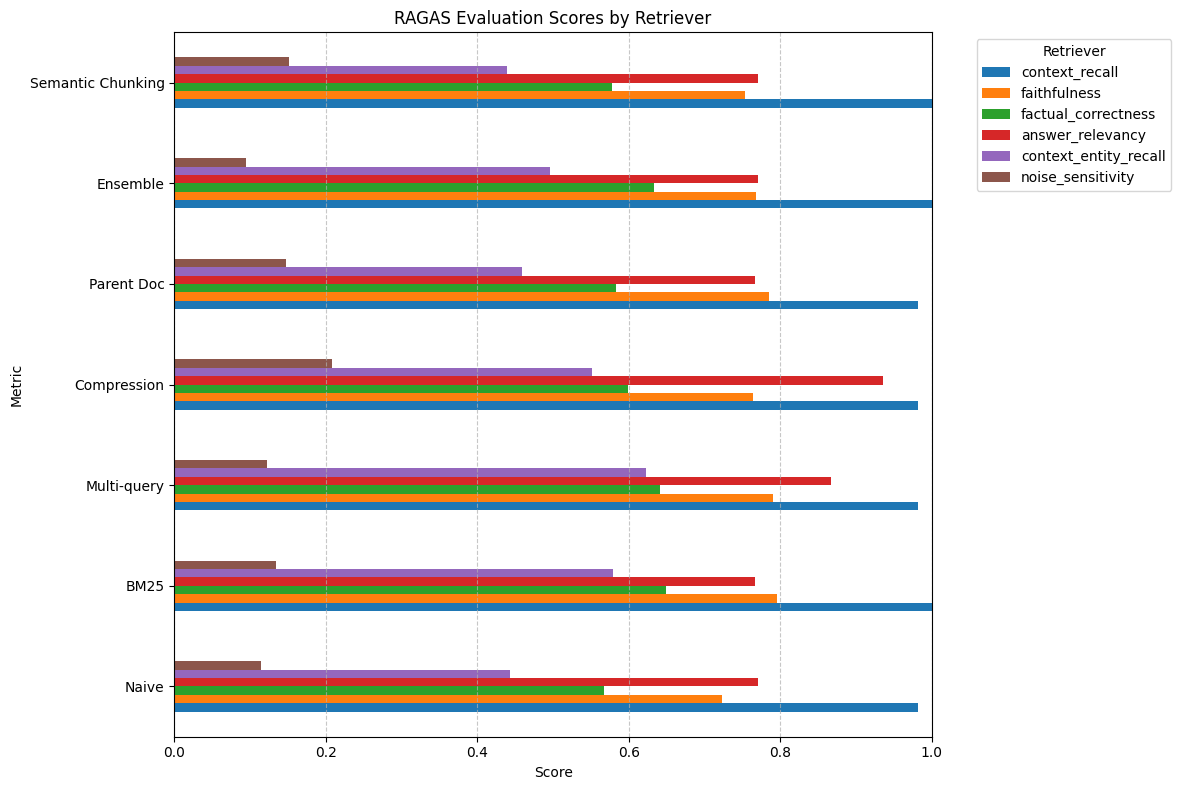

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

retriever_scores = {
    "Naive": {
        'context_recall': 0.9818, 'faithfulness': 0.7230,
        'factual_correctness': 0.5673, 'answer_relevancy': 0.7705,
        'context_entity_recall': 0.4426, 'noise_sensitivity': 0.1146
    },
    "BM25": {
        'context_recall': 1.0000, 'faithfulness': 0.7954,
        'factual_correctness': 0.6491, 'answer_relevancy': 0.7667,
        'context_entity_recall': 0.5790, 'noise_sensitivity': 0.1337
    },
    "Multi-query": {
        'context_recall': 0.9818, 'faithfulness': 0.7907,
        'factual_correctness': 0.6409, 'answer_relevancy': 0.8675,
        'context_entity_recall': 0.6229, 'noise_sensitivity': 0.1220
    },
    "Compression": {
        'context_recall': 0.9818, 'faithfulness': 0.7643,
        'factual_correctness': 0.5991, 'answer_relevancy': 0.9355,
        'context_entity_recall': 0.5511, 'noise_sensitivity': 0.2079
    },
    "Parent Doc": {
        'context_recall': 0.9818, 'faithfulness': 0.7850,
        'factual_correctness': 0.5836, 'answer_relevancy': 0.7663,
        'context_entity_recall': 0.4593, 'noise_sensitivity': 0.1468
    },
    "Ensemble": {
        'context_recall': 1.0000, 'faithfulness': 0.7675,
        'factual_correctness': 0.6336, 'answer_relevancy': 0.7700,
        'context_entity_recall': 0.4957, 'noise_sensitivity': 0.0951
    },
    "Semantic Chunking": {
        'context_recall': 1.0000, 'faithfulness': 0.7537,
        'factual_correctness': 0.5773, 'answer_relevancy': 0.7703,
        'context_entity_recall': 0.4389, 'noise_sensitivity': 0.1508
    }
}

df_scores = pd.DataFrame(retriever_scores).T 

df_plot = df_scores.round(4)

ax = df_plot.plot(kind='barh', figsize=(12, 8))
plt.title("RAGAS Evaluation Scores by Retriever")
plt.xlabel("Score")
plt.ylabel("Metric")
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title="Retriever", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

